In [1]:
%matplotlib inline
# %matplotlib notebook
from sklearn.model_selection import train_test_split
import numpy as np
import qutip as qt
from entVAE import vae_utils 
from qiskit.quantum_info import Statevector, DensityMatrix
import matplotlib.pyplot as plt
import tensorflow as tf


I0000 00:00:1779100912.937254   39519 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779100912.964787   39519 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779100914.164932   39519 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.4,
        "ytick.major.width": 0.4,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 8,
    }
)

In [3]:
n_angle = 101
n_samples = 1000
scan_arr = np.linspace(0, np.pi, n_angle)
alpha_arr = np.zeros(101000)
cnt = 0
for theta in scan_arr:
        for _ in (range(n_samples)):
            alpha_arr[cnt] = theta
            cnt += 1

# Noiseless Dataset

Load Dataset

In [4]:
rho_arr_noiseless = np.load('../data/unitary_4x4_101_1000_noiseless.npy', mmap_mode="r")
X_train_noiseless, X_test_noiseless, y_train_noiseless, y_test_noiseless = train_test_split(rho_arr_noiseless, alpha_arr, random_state=42)
concurrence_noiseless_arr = np.array([qt.concurrence(qt.Qobj(dm.reshape(4,4),dims=[[2,2],[2,2]])) for dm in X_test_noiseless])

Define Hyperparameters and load trained VAE:

In [5]:
batch_size = 64
beta = 0.0
learning_rate = 0.0001
lat_dim = 1

encoder, decoder = vae_utils.vae_mlp_4x4(lat_dim, "relu", "tanh")
encoder.load_weights("../data/encoder_noiseless.h5")
decoder.load_weights("../data/decoder_noiseless.h5")

vae_noiseless = vae_utils.VAE(encoder, decoder, beta)
vae_noiseless.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))
# vae_noiseless.fit(X_test_noiseless, epochs=1, batch_size=64, verbose=1) 

z_mean_noiseless, z_log_var_noiseless, z_noiseless = vae_noiseless.encoder.predict(X_test_noiseless)

790/790 ━━━━━━━━━━━━━━━━━━━━ 1s 673us/step


In [6]:
colors = ["#E64B35", "#4DBBD5", "#00A087", "#3C5488", "#F39B7F", "#8491B4"]
markers = ["o", "s", "^", "D", "v", "p"]

MS = 5 
LW = 1.2 
MW = 0.5

# Noisy Dataset  $0.75\beta$

Load Dataset

In [7]:
rho_arr_noisy = np.load('../data/unitary_4x4_101_1000.npy', mmap_mode="r")
X_train_noisy, X_test_noisy, y_train_noisy, y_test_noisy = train_test_split(rho_arr_noisy, alpha_arr, random_state=42)
concurrence_noisy_arr = np.array([qt.concurrence(qt.Qobj(dm.reshape(4,4),dims=[[2,2],[2,2]])) for dm in X_test_noisy])

Load trained VAE and define Hyperparameters:

In [8]:
batch_size = 64
beta = 0.75
learning_rate = 0.0001
lat_dim = 1
hidden_act = "tanh"
final_act = "linear"

encoder, decoder = vae_utils.vae_mlp_4x4(lat_dim, hidden_act, final_act)
encoder.load_weights("../data/encoder_noise_075beta.h5")
decoder.load_weights("../data/decoder_noise_075beta.h5")

vae_noisy = vae_utils.VAE(encoder, decoder, beta)
vae_noisy.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate))

z_mean_noisy, z_log_var_noisy, z_noisy = vae_noisy.encoder.predict(X_test_noisy)

790/790 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step


# Figures 

In [10]:
lat_arr = np.arange(1,9)
n_exp = 9

recon_loss_noiseless = np.zeros((len(lat_arr),n_exp, 1))
recon_loss_noise = np.zeros((len(lat_arr),n_exp, 1))
recon_loss_noise_075 = np.zeros((len(lat_arr),n_exp, 1))


for cnt_1, inx in enumerate(lat_arr):
    for cnt_2 in range(n_exp):
        read_dictionary = np.load('../data/no_0beta_latent/history_{}_1_{}.npy'.format(inx,cnt_2),allow_pickle='TRUE').item()
        recon_loss_noiseless[cnt_1][cnt_2] = read_dictionary["reconstruction_loss"][-1]
        
        read_dictionary = np.load('../data/noise_0beta_latent/history_{}_1_{}.npy'.format(inx,cnt_2),allow_pickle='TRUE').item()
        recon_loss_noise[cnt_1][cnt_2] = read_dictionary["reconstruction_loss"][-1]
        
        read_dictionary = np.load('../data/noise_075beta_latent/history_{}_1_{}.npy'.format(inx,cnt_2),allow_pickle='TRUE').item()
        recon_loss_noise_075[cnt_1][cnt_2] = read_dictionary["reconstruction_loss"][-1]

av_recon_loss_arr_noiseless = np.average(recon_loss_noiseless,axis=1)
std_recon_loss_arr_noiseless = np.std(recon_loss_noiseless,axis=1)

av_recon_loss_arr_noise = np.average(recon_loss_noise,axis=1)
std_recon_loss_arr_noise = np.std(recon_loss_noise,axis=1)

av_recon_loss_arr_noise_075 = np.average(recon_loss_noise_075,axis=1)
std_recon_loss_arr_noise_075 = np.std(recon_loss_noise_075,axis=1)

In [11]:
selected_alpha_noiseless, selected_conc_noiseless, selected_z_noiseless, pred_conc_noiseless, pred_alpha_noiseless, fitobj_conc_noiseless, fitobj_alpha_noiseless = vae_utils.gen_plot_data(rho_arr_noiseless, vae_noiseless, scan_arr)  
selected_alpha_noisy, selected_conc_noisy, selected_z_noisy, pred_conc_noisy, pred_alpha_noisy, fitobj_conc_noisy, fitobj_alpha_noisy = vae_utils.gen_plot_data(rho_arr_noisy, vae_noisy, scan_arr)  
selected_alpha_generalized, selected_conc_generalized, selected_z_generalized, pred_conc_generalized, pred_alpha_generalized, fitobj_conc_generalized, fitobj_alpha_generalized = vae_utils.gen_plot_data(rho_arr_noiseless, vae_noisy, scan_arr)      

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [12]:
def get_dm():
    state = Statevector.from_int(0, 2**2)
    return DensityMatrix(state)

def get_random_u(n):
    z = np.random.randn(n,n)/np.sqrt(2.0)
    q,r = np.linalg.qr(z)
    d = np.diagonal(r)
    ph = d/np.absolute(d)
    q = np.multiply(q,ph,q)
    return q

def apply_u(dm, U):
    return  U * dm * U.dag() 



def gen_data_rand():
    cnt = 0 
    data_arr = np.zeros((210,16))
    conc_arr = np.zeros((210))
    
    for c_arr in selected_conc_noisy:
        for c in c_arr:
            Found = False
            while not Found:
                trial_state = apply_u(qt.Qobj(get_dm().data,dims=[[2,2],[2,2]]), qt.Qobj(get_random_u(4),dims=[[2,2],[2,2]]))
                
                if np.abs(np.array(trial_state.full()).imag).sum() == 0 and np.isclose(qt.concurrence(trial_state),c,atol=2e-2):
                    data_arr[cnt] = np.array(trial_state.full()).real.flatten()
                    conc_arr[cnt] = qt.concurrence(trial_state)
                    
                    cnt += 1 
                    Found = True
                    print(cnt)
            
    return data_arr, conc_arr

rand_data_arr, rand_conc_arr = gen_data_rand()

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210


In [13]:
random_unitary_arr = rand_data_arr
z_mean_ru, _, _ = vae_noisy.encoder.predict(random_unitary_arr)
concur_arr_ru = np.array([qt.concurrence(qt.Qobj(dm.reshape(4,4),dims=[[2,2],[2,2]])) for dm in random_unitary_arr])
pred_conc_ru = vae_utils.linear_fit(np.abs(z_mean_ru[:,0]),concur_arr_ru)[0]
z_mean_ru = np.reshape(z_mean_ru,(21,10))    
concur_arr_ru = np.reshape(concur_arr_ru,(21,10))
pred_conc_ru = np.reshape(pred_conc_ru,(21,10))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [19]:
# Werner-state dataset generated with QuTiP for gamma in [0, 1]
gamma_small = np.linspace(0.0, 2/3, 21)

# Bell state |Phi+> = (|00> + |11>)/sqrt(2)
phi_plus = (qt.tensor(qt.basis(2, 0), qt.basis(2, 0)) + qt.tensor(qt.basis(2, 1), qt.basis(2, 1))).unit()
rho_pi = qt.ket2dm(phi_plus)

# Two-qubit maximally mixed state I/4
id4 = qt.qeye([2, 2])

# rho_d(gamma) = (1-gamma) * rho_pi + (gamma/4) * I
rho_werner_qobj = [(1.0 - g) * rho_pi + (g / 4.0) * id4 for g in gamma_small]

# Flatten to length-16 vectors to match model input convention used in this notebook
rho_werner_flat = np.array([rho.full().reshape(-1) for rho in rho_werner_qobj])

# Concurrence of each state
conc_werner = np.array([qt.concurrence(rho) for rho in rho_werner_qobj])

print('gamma_small:', gamma_small)
print('rho_werner_flat shape:', rho_werner_flat.shape)
print('conc_werner:', conc_werner)



gamma_small: [0.         0.03333333 0.06666667 0.1        0.13333333 0.16666667
 0.2        0.23333333 0.26666667 0.3        0.33333333 0.36666667
 0.4        0.43333333 0.46666667 0.5        0.53333333 0.56666667
 0.6        0.63333333 0.66666667]
rho_werner_flat shape: (21, 16)
conc_werner: [1.   0.95 0.9  0.85 0.8  0.75 0.7  0.65 0.6  0.55 0.5  0.45 0.4  0.35
 0.3  0.25 0.2  0.15 0.1  0.05 0.  ]


In [20]:
def c_test(rho):
    sysy = qt.tensor(qt.sigmay(), qt.sigmay())
    rho_tilde = (rho * sysy) * (rho.conj() * sysy)
    evals = rho_tilde.eigenenergies()
    evals = abs(np.sort(np.real(evals)))
    lsum = np.sqrt(evals[3]) - np.sqrt(evals[2]) - np.sqrt(evals[1]) - np.sqrt(evals[0])

    return lsum

test_c = np.array([c_test(dm) for dm in rho_werner_qobj])

In [21]:
z_mean_gamma, _, _ = vae_noisy.encoder.predict(rho_werner_flat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [22]:
def linear_fit(x, y):
    arr_len = int(len(x)/10)
    fit_obj = np.polyfit(x, y, 1)
    fit_pred = np.poly1d(fit_obj)
    return np.reshape(fit_pred(x), (arr_len, 10)), fit_pred

# conc_werner vs z_mean_gamma 
fit_obj = np.polyfit(conc_werner.flatten(), z_mean_gamma.flatten(), 1)
fit_pred = np.poly1d(fit_obj)

# 2. Generate predictions (Pass the X variable here!)
y_gamma_fit = fit_pred(conc_werner.flatten())

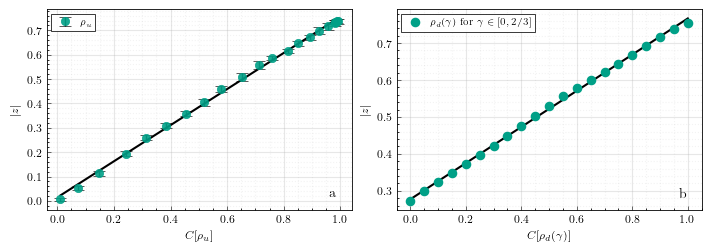

In [23]:
fig,ax = plt.subplots(1,2, figsize=(7.0, 2.4), constrained_layout=True)

ax[0].errorbar(np.mean(concur_arr_ru,axis=1),
               np.mean(np.abs(z_mean_ru),axis=1),
               np.std(np.abs(z_mean_ru),axis=1),
               label="$\\rho_u$",
               marker="o",
               ls='',
                markeredgewidth=0.5,
                capsize=4, 
                capthick=1, 
                elinewidth=1,
                alpha=0.9,
                ecolor='black',
                color=colors[2],
                zorder=3
                )

ax[0].plot(np.mean(concur_arr_ru,axis=1), np.mean(linear_fit( concur_arr_ru.flatten(),np.abs(z_mean_ru).flatten())[0] ,axis=1),c="black")


ax[1].plot(
        conc_werner,
        z_mean_gamma,
        "o",
        c=colors[2],
        label="$\\rho_d(\\gamma)$ for $\\gamma \\in [0, 2/3]$",
        markersize=6,
        markeredgewidth=0.9,
        zorder=3
    )


ax[1].plot(conc_werner, y_gamma_fit ,c="black")

ax[0].set_ylabel("$|z|$")
ax[1].set_ylabel("$|z|$")

ax[0].set_xlabel("$C[\\rho_u]$")
ax[1].set_xlabel("$C[\\rho_d(\\gamma)]$")

ax[0].text(
        0.95, 0.05,  # x=95% right, y=5% from bottom (in axes coords)
        "a",
        transform=ax[0].transAxes,
        va='bottom',
        ha='right',
        fontsize=10
    )

ax[1].text(
        0.95, 0.05,  # x=95% right, y=5% from bottom (in axes coords)
        "b",
        transform=ax[1].transAxes,
        va='bottom',
        ha='right',
        fontsize=10
    )


legend = ax[0].legend(
        frameon=True,
        loc="best",
        fontsize=7,
        ncol=1,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
    )
legend.get_frame().set_linewidth(0.6)

legend = ax[1].legend(
        frameon=True,
        loc="best",
        fontsize=7,
        ncol=1,
        columnspacing=1.0,
        handletextpad=0.5,
        framealpha=0.9,
        edgecolor="black",
        fancybox=False,
    )
legend.get_frame().set_linewidth(0.6)

for a in ax:

    a.grid(True, which="major", linestyle="-", alpha=0.3)
    a.grid(True, which="minor", linestyle=":", alpha=0.15)

    a.tick_params(direction="in", which="both", labelsize=8)
    a.tick_params(which="major", length=3)
    a.tick_params(which="minor", length=1.5)
    a.minorticks_on()

# plt.savefig("fig_exp5_new.pdf",bbox_inches="tight",pad_inches=0.1)